# Model Implementation

## Imports

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os
from pathlib import Path

from joblib import dump
import json, os, sklearn, sys, platform, pathlib
import joblib

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

from sklearn.metrics import classification_report, confusion_matrix, average_precision_score
from sklearn.metrics import precision_recall_curve,

from sklearn.inspection import permutation_importance
import shap

c:\Users\adris\OneDrive\Desktop\datascientist_project_remake\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
PROJECT_ROOT = Path.cwd().resolve().parent

save_dir = PROJECT_ROOT / 'reports' / 'figures' / '02_model_implementation'
save_art = PROJECT_ROOT / 'reports' / 'artifacts' / '02_model_implementation' 

In [6]:
data_path = PROJECT_ROOT / "data" / "data_preprocessed.csv"

data = pd.read_csv(data_path)

In [7]:
data.head()

,months_as_customer,policy_deductable,policy_annual_premium,umbrella_limit,incident_type,collision_type,incident_severity,authorities_contacted,property_damage,total_claim_amount,fraud_reported,injury_share,vehicle_share,property_share,claim_to_premium,claim_to_deductible,has_umbrella_policy
0,328,1000,1406.91,0,Single Vehicle Collision,Side Collision,Major Damage,Police,YES,71610,1,0.090909,0.727273,0.181818,50.898778,71.610,0
1,228,2000,1197.22,5000000,Vehicle Theft,No Collision,Minor Damage,Police,Not recorded,5070,1,0.153846,0.692308,0.153846,4.234811,2.535,1
2,134,2000,1413.14,5000000,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NO,34650,0,0.222222,0.666667,0.111111,24.519864,17.325,1
3,256,2000,1415.74,6000000,Single Vehicle Collision,Front Collision,Major Damage,Police,Not recorded,63400,1,0.100000,0.800000,0.100000,44.782234,31.700,1
4,228,1000,1583.91,6000000,Vehicle Theft,No Collision,Minor Damage,Police,NO,6500,0,0.200000,0.700000,0.100000,4.103769,6.500,1


## Test and Train Set Split

In [8]:
X = data.drop(['fraud_reported'], axis = 1)
y = data['fraud_reported']

In [9]:
print(f'X contains {X.shape[0]} rows and {X.shape[1]} columns.')

X contains 1000 rows and 16 columns.


In [10]:
y.shape

(1000,)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, stratify = y, random_state = 42)

Since we have an imbalance in the target variable, we use the stratify parameter to ensure that the class distribution is preserved in both the training and test sets. So they have similiar proportion of each class.

## Encoding and Scaling

**Encoding & Scaling (based on EDA findings)**:

The final dataset contains some heavy-tailed monetary/ratio features, therefore I avoid automatic outlier removal (extreme values may carry fraud signal).<br>
For scale-sensitive models (e.g., Logistic Regression) I apply scaling (Robust/Standard Scaler) after encoding.<br> For tree-based models (Random Forest) scaling is not required, but we keep preprocessing consistent where helpful.

I keep `total_claim_amount` for now and later validate whether it introduces leakage by checking its contribution (e.g., permuation imprtance)

In [12]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   months_as_customer     1000 non-null   int64  
 1   policy_deductable      1000 non-null   int64  
 2   policy_annual_premium  1000 non-null   float64
 3   umbrella_limit         1000 non-null   int64  
 4   incident_type          1000 non-null   object 
 5   collision_type         1000 non-null   object 
 6   incident_severity      1000 non-null   object 
 7   authorities_contacted  1000 non-null   object 
 8   property_damage        1000 non-null   object 
 9   total_claim_amount     1000 non-null   int64  
 10  injury_share           1000 non-null   float64
 11  vehicle_share          1000 non-null   float64
 12  property_share         1000 non-null   float64
 13  claim_to_premium       1000 non-null   float64
 14  claim_to_deductible    1000 non-null   float64
 15  has_u

In [13]:
# Encoding Features

ord_cols = ['incident_severity']
ord_order = [['Trivial Damage', 'Minor Damage', 'Major Damage', 'Total Loss']]

ohe_cols = ['incident_type', 'authorities_contacted', 'property_damage', 'collision_type']

# Scaling Features

std_cols = [
    'total_claim_amount',
    'policy_deductable',
    'policy_annual_premium',
    'months_as_customer',
    'claim_to_deductible',
    'claim_to_premium',
    'vehicle_share',
    'property_share',
    'injury_share'
]

In [14]:
# Preprocessor for Logistic Regression

preprocessor_logreg = ColumnTransformer([
    ('ord', OrdinalEncoder(categories = ord_order), ord_cols),
    ('ohe', OneHotEncoder(drop = 'first', handle_unknown = 'ignore', sparse_output = False), ohe_cols),
    ('std', StandardScaler(), std_cols),
    ('rob', RobustScaler(), ['umbrella_limit'])
],
                                 remainder = 'passthrough',
                                 verbose_feature_names_out = True,
                                 )


# Preprocessor for Random Forest

preprocessor_rf = ColumnTransformer([
    ('ord', OrdinalEncoder(categories = ord_order), ord_cols),
    ('ohe', OneHotEncoder(drop = 'first', handle_unknown = 'ignore', sparse_output = False), ohe_cols),
], 
                                 remainder = 'passthrough',
                                 verbose_feature_names_out = True,
                                 )

## Visualize Target 

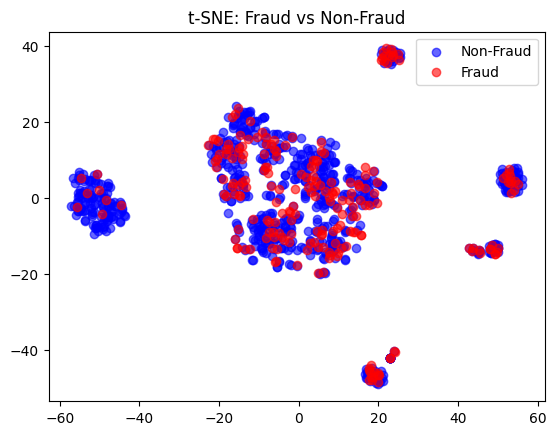

In [15]:
X_train_processed = preprocessor_logreg.fit_transform(X_train)

tsne = TSNE(n_components = 2, random_state = 42, max_iter = 1000)
X_train_tsne = tsne.fit_transform(X_train_processed)

plt.scatter(X_train_tsne[y_train.values==0, 0], X_train_tsne[y_train.values==0, 1], alpha = 0.6, label = 'Non-Fraud', c = 'blue')
plt.scatter(X_train_tsne[y_train.values==1, 0], X_train_tsne[y_train.values==1, 1], alpha=0.6, label='Fraud', c='red')
plt.legend()
plt.title('t-SNE: Fraud vs Non-Fraud')
plt.savefig(save_dir / 't_sne_plot_target.png')
plt.show();

**t-SNE**:

I use *t-SNE* as an exploratory, low-dimensional projection to build intuition about class overlap. The plot shows substantial overlap between fraud and non-fraud observations, suggesting that separation is not straightforward.<br>

## Baseline Model

### Logistic Regression

I train a simple Logistic Regression baseline to benchmark performance on this imbalanced classification problem. I use **class_weight = 'balanced'** and evaluate with **PR-AUC** and fraud-class metrics. This baseline serves as a reference point before moving to non-linear models.

In [16]:
lr_pipe= Pipeline([
    ('preprocessor', preprocessor_logreg),
    ('clf', LogisticRegression(class_weight = 'balanced',
                               max_iter = 5000,
                               solver = 'lbfgs'
                               ))
])


lr_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [17]:
threshold = 0.5

proba_lr = lr_pipe.predict_proba(X_test)[:,1]
pred_lr = (proba_lr > threshold).astype(int)


pr_auc = average_precision_score(y_test, proba_lr)
print('PR-AUC =', round(pr_auc, 4))
print('\nConfusion Matrix (threshold = 0.5)')
print(confusion_matrix(y_test, pred_lr))
print('\nClassification Report (threshold = 0.5)')
print(classification_report(y_test, pred_lr, digits = 4))

PR-AUC = 0.3749

Confusion Matrix (threshold = 0.5)
[[18 57]
 [ 2 23]]

Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

           0     0.9000    0.2400    0.3789        75
           1     0.2875    0.9200    0.4381        25

    accuracy                         0.4100       100
   macro avg     0.5938    0.5800    0.4085       100
weighted avg     0.7469    0.4100    0.3937       100



In [19]:
report_lr = classification_report(y_test, pred_lr, output_dict = True)
report_lr_df = pd.DataFrame(report_lr).T

report_lr_df.to_csv(save_art / 'classification_report_lr_base.csv', index = True)
print('Saving completed')

Saving completed


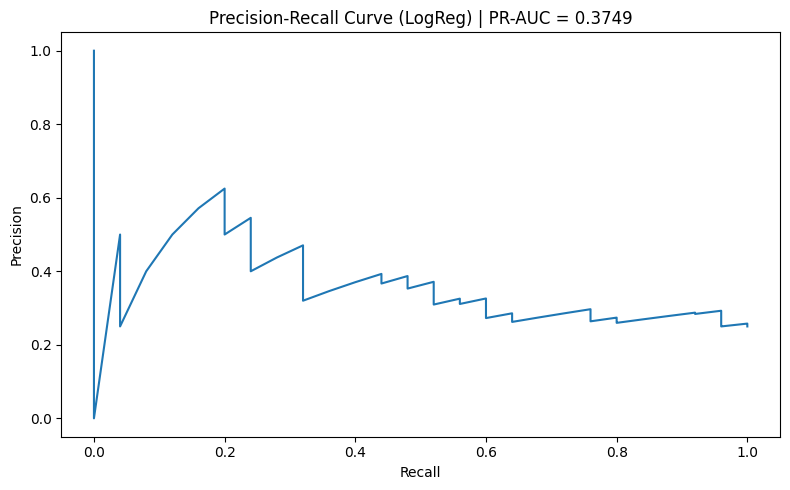

In [21]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_lr)
pr_auc = average_precision_score(y_test, proba_lr)

plt.figure(figsize = (8, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (LogReg) | PR-AUC = {pr_auc:.4f}')
plt.tight_layout()
plt.savefig(save_dir / 'pr_curve_logreg.png', dpi = 200)
plt.show()

The PR curve shows that increasing recall substantially reduces precision, suggesting limited separability with a linear decision boundary.

The *logistic regression baseline* achieves high recall for the fraud class but produces many false positives, leading to low specificity for the non-fraud class.<br> This indicates limited separation with a linear decision boundary, so I move on to tree-based models for better non-linear modelling and feature interactions.

## Tree-based Ensemble Model

In this project I prioritise detecting fraud cases (high recall), but I also account for operational cost by requiring an acceptable precision level.<br> Therefore, I choose the decision threshold by maximising recall subject to a minimum precision constraint on a validation split.

### Random Forest - Base Model

Train a baseline Random Forest model without any resampling techniques.   
Predictions are made using the default probability threshold of 0.50.

In [23]:
rf_pipe_base = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('clf', RandomForestClassifier(n_estimators = 300,
                                   class_weight = 'balanced_subsample',
                                   random_state = 42))
])

rf_pipe_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [24]:
threshold = 0.5
rf_proba = rf_pipe_base.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba > 0.50).astype(int)

pr_auc = average_precision_score(y_test, rf_proba)
print('PR-AUC =', round(pr_auc, 4))

print('\nConfusion Matrix (threshold = 0.5)')
print(confusion_matrix(y_test, rf_pred))

print('\nClassification Report (threshold = 0.5)')
print(classification_report(y_test, rf_pred, digits = 4))

PR-AUC = 0.5588

Confusion Matrix (threshold = 0.5)
[[71  4]
 [21  4]]

Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

           0     0.7717    0.9467    0.8503        75
           1     0.5000    0.1600    0.2424        25

    accuracy                         0.7500       100
   macro avg     0.6359    0.5533    0.5464       100
weighted avg     0.7038    0.7500    0.6983       100



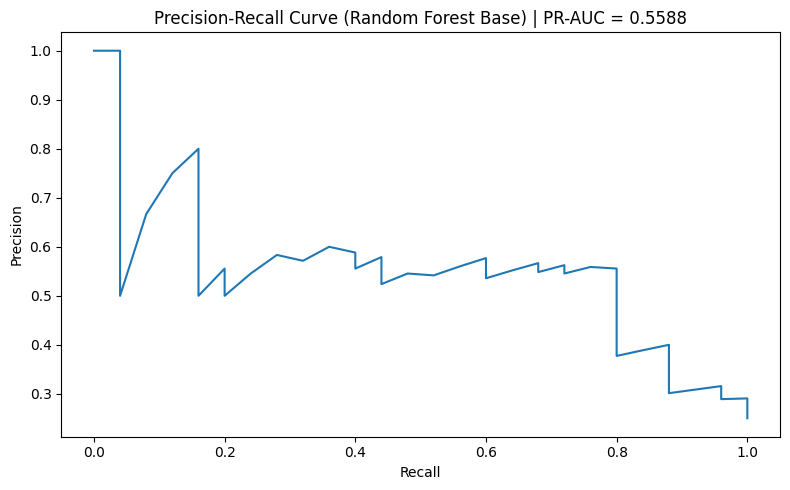

In [26]:
precision, recall, thresholds = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize = (8, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (Random Forest Base) | PR-AUC = {pr_auc:.4f}')
plt.tight_layout()
plt.savefig(save_dir / 'pr_curve_rf_base.png', dpi = 200)
plt.show()

The *Random Forest baseline* improves ranking performance substantially compared to the logistic regression baseline (PR-AUC increases from 0.3749 to 0.5588).<br> However, at the default threshold of 0.5 the model yields low fraud recall (0.16), indicating that threshold calibration is required for this imbalanced setting.<br> Therefore, I optimise the decision threshold later in a dedicated step rather than relying on 0.5.

In [25]:
report_rf_base = classification_report(y_test, rf_pred, output_dict = True)
report_rf_base_df = pd.DataFrame(report_rf_base).T
report_rf_base_df.to_csv(save_art / 'classification_report_rf_base.csv', index = True)
print('Saving completed')

Saving completed


#### Threshold Tuning

**Threshold tuning (validation split)**:
I tune the decision threshold on a validation split to maximise fraud recall while enforcing a minimum precision constraint. I then evaluate the selected threshold on the test set.

In [36]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size = 0.2, random_state = 42, stratify = y_train
)

In [30]:
def threshold_opt_recall_with_precision(
    y_true,
    y_proba,
    precision_min = 0.35,
    plot = True,
    verbose = True,
    title = 'Threshold Optimization',
    save_dir = None,
    save_plot = None
):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    precision_t = precision[1:]
    recall_t = recall[1:]
    thr = thresholds

    mask = precision_t >= precision_min
    if mask.any():
        best_idx = np.arange(len(thr))[mask][np.argmax(recall_t[mask])]
    else:
        best_idx = int(np.argmax(precision_t))
        if verbose:
            print('No threshold meets the minimum precision constraint. I fall back to maximising precision.')

    best_t = float(thr[best_idx])
    best_precision = float(precision_t[best_idx])
    best_recall = float(recall_t[best_idx])

    if plot:
        plt.figure(figsize = (10, 6))
        plt.plot(thr, precision_t, label = 'Precision')
        plt.plot(thr, recall_t, label = 'Recall')
        plt.axvline(x = best_t, linestyle = ':', label = f'Best threshold = {best_t:.4f}')
        plt.axhline(precision_min, linestyle = '--', alpha = 0.6, label = f'Precision ≥ {precision_min:.2f}')
        plt.title(title)
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)


        if save_dir is not None and save_plot is not None:
            plt.savefig(save_dir / f'{save_plot}.png', dpi = 200)

        plt.show()

    if verbose:
        print(f'Optimal threshold: {best_t:.4f}  (Precision = {best_precision:.4f}, Recall = {best_recall:.4f})')

    return best_t, best_precision, best_recall


In [ ]:
# Validation split for threshold tuning (I keep stratification due to class imbalance)

rf_pipe_base_tuned = Pipeline([
    ( 'preprocessor', preprocessor_rf ),
    ( 'clf', RandomForestClassifier(
        random_state = 42,
        n_estimators = 300,
        class_weight = 'balanced_subsample'
    ) )
])

rf_pipe_base_tuned.fit(X_tr, y_tr)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

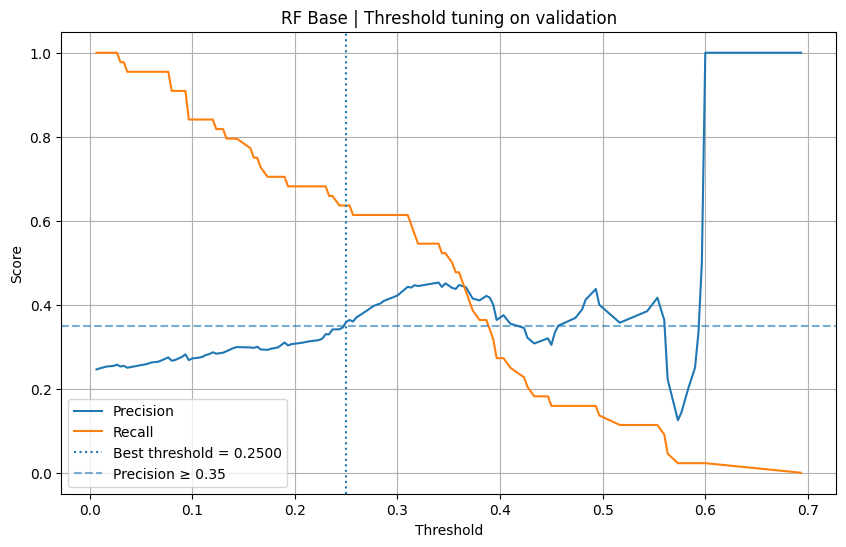

Optimal threshold: 0.2500  (Precision = 0.3590, Recall = 0.6364)


In [62]:
val_proba = rf_pipe_base_tuned.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, val_proba)

best_t_rf_base, best_p_rf_base, best_r_rf_base = threshold_opt_recall_with_precision(
    y_true = y_val,
    y_proba = val_proba,
    precision_min = 0.35,
    plot = True,
    verbose = True,
    title = 'RF Base | Threshold tuning on validation',
    save_dir = save_dir,
    save_plot = 'threshold_tuning_rf_base'
)

In [ ]:
# Final evaluation on test with the tuned threshold

test_proba = rf_pipe_base_tuned.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_t_rf_base).astype(int)

print('\nConfusion Matrix (tuned threshold)')
print(confusion_matrix(y_test, test_pred))

print('\nClassification Report (tuned threshold)')
print(classification_report(y_test, test_pred, digits = 4))


Confusion Matrix (tuned threshold)
[[52 23]
 [ 5 20]]

Classification Report (tuned threshold)
              precision    recall  f1-score   support

           0     0.9123    0.6933    0.7879        75
           1     0.4651    0.8000    0.5882        25

    accuracy                         0.7200       100
   macro avg     0.6887    0.7467    0.6881       100
weighted avg     0.8005    0.7200    0.7380       100



In [35]:
report_rf_base_tuned = classification_report(y_test, test_pred, output_dict = True)
report_rf_base_tuned_df = pd.DataFrame(report_rf_base_tuned).T
report_rf_base_tuned_df.to_csv(save_art / 'classification_report_rf_base_tuned.csv', index = True)
print('Saving completed')

Saving completed


After threshold tuning on a validation split (maximising fraud recall subject to a minimum precision constraint), the *Random Forest baseline* improves fraud detection substantially.<br> Fraud recall increases from *0.16* at the default threshold to *0.80* at the tuned threshold (t = 0.25), reducing false negatives from 21 to 5.<br> This comes at the cost of more false positives, which reflects the expected operational trade-off in fraud screening.

In practice, this means fewer fraudulent claims slip through, while more claims are flagged for manual review.

### Random Forest - SMOTE

In [37]:
rf_pipe_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])

In [38]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

param_grid_rf_smote = {
    'clf__n_estimators' : [ 300, 600 ],
    'clf__max_depth' : [ None, 10, 20 ],
    'clf__min_samples_split' : [ 2, 5 ],
    'clf__min_samples_leaf' : [ 1, 2 ],
    'clf__max_features' : [ 'sqrt', 'log2' ]
}

grid_rf_smote = GridSearchCV(
    rf_pipe_smote,
    param_grid_rf_smote,
    cv = cv,
    scoring = 'average_precision',
)

grid_rf_smote.fit(X_tr, y_tr)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__max_depth': [None, 10, ...], 'clf__max_features': ['sqrt', 'log2'], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the 

In [39]:
best_rf_smote = grid_rf_smote.best_estimator_
params_rf_smote = grid_rf_smote.best_params_
score_rf_smote = grid_rf_smote.best_score_

print('Best params =', params_rf_smote)
print('Best CV PR-AUC =', round(score_rf_smote, 4))

Best params = {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 600}
Best CV PR-AUC = 0.5392


#### Threshold Tuning

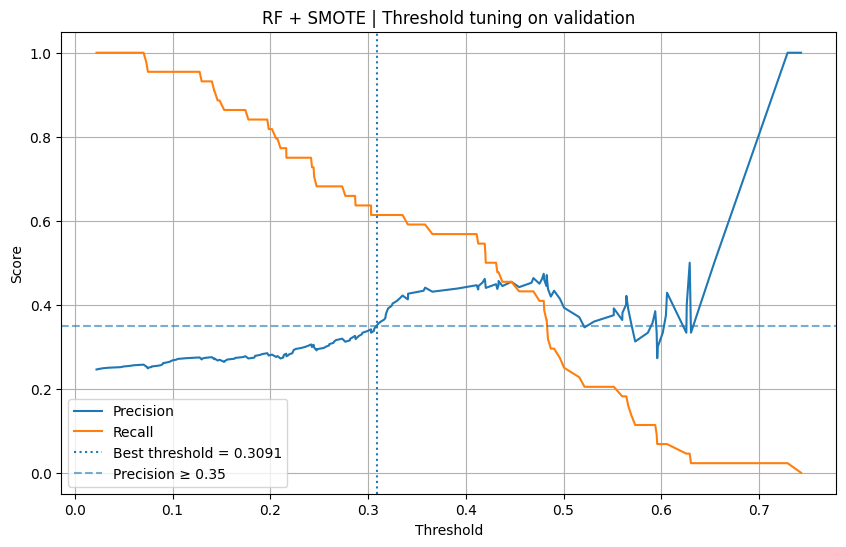

Optimal threshold: 0.3091  (Precision = 0.3506, Recall = 0.6136)


In [61]:
val_proba = best_rf_smote.predict_proba(X_val)[:, 1]

best_t_rf_smote, best_p_rf_smote, best_r_rf_smote = threshold_opt_recall_with_precision(
    y_true = y_val,
    y_proba = val_proba,
    precision_min = 0.35,
    plot = True,
    verbose = True,
    title = 'RF + SMOTE | Threshold tuning on validation',
    save_dir = save_dir,
    save_plot = 'threshold_tuning_rf_smote'
)

In [ ]:
test_proba_rf_smote = best_rf_smote.predict_proba(X_test)[:, 1]
test_pred_rf_smote = (test_proba_rf_smote >= best_t_rf_smote).astype(int)

pr_auc_rf_smote_test = average_precision_score(y_test, test_proba_rf_smote)
print('\nTest PR-AUC =', round(pr_auc_rf_smote_test, 4))

print('\nConfusion Matrix (tuned threshold)')
print(confusion_matrix(y_test, test_pred_rf_smote))

print('\nClassification Report (tuned threshold)')
print(classification_report(y_test, test_pred_rf_smote, digits = 4))


Test PR-AUC = 0.619

Confusion Matrix (tuned threshold)
[[56 19]
 [ 4 21]]

Classification Report (tuned threshold)
              precision    recall  f1-score   support

           0     0.9333    0.7467    0.8296        75
           1     0.5250    0.8400    0.6462        25

    accuracy                         0.7700       100
   macro avg     0.7292    0.7933    0.7379       100
weighted avg     0.8313    0.7700    0.7838       100



In [45]:
report_rf_smote = classification_report(y_test, test_pred_rf_smote, output_dict = True)
report_rf_smote_df = pd.DataFrame(report_rf_smote).T
report_rf_smote_df.to_csv(save_art / 'classification_report_rf_smote_tuned.csv', index = True)
print('Saving completed')

Saving completed


Compared to the tuned *Random Forest baseline*, the SMOTE variant improves fraud detection while reducing false positives. With the tuned threshold, fraud recall increases to **0.84** and precision to **0.53**, and false negatives drop to 4. This indicates that SMOTE can help in this setting when combined with explicit threshold calibration.

### Random Forest - SMOTE + Feature Selection

**Random Forest + Feature Selection**:

I apply embedded feature selection using a tree-based model to reduce noise and improve generalisation. I tune the Random Forest hyperparameters with stratified cross-validation on the training split and select the decision threshold on a separate validation split by maximising fraud recall subject to a minimum precision constraint.

In [47]:
fs_model = RandomForestClassifier(n_estimators = 300,
                                  class_weight = 'balanced_subsample',
                                  random_state = 42)

rf_pipe_fs = ImbPipeline([
    ('preprocessor', preprocessor_rf),
    ('smote', BorderlineSMOTE(random_state = 42)),
    ('select', SelectFromModel(estimator = fs_model, threshold = 'median'
    )),
    ('clf', RandomForestClassifier(random_state=42))
])

In [48]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

rf_params_fs = {
    'select__threshold': ['mean', 'median'],
    'clf__n_estimators': [200, 250, 300, 600],
    'clf__max_depth': [None, 10, 20, 30],
    'clf__min_samples_split' : [ 2, 5 ],
    'clf__min_samples_leaf' : [ 1, 2 ],
    'clf__max_features' : [ 'sqrt', 'log2' ]
} 


grid_rf_fs = GridSearchCV(rf_pipe_fs,
                      rf_params_fs,
                      cv = cv,
                      scoring = 'average_precision',
                      )

grid_rf_fs.fit(X_tr, y_tr)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__max_depth': [None, 10, ...], 'clf__max_features': ['sqrt', 'log2'], 'clf__min_samples_leaf': [1, 2], 'clf__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the 

In [49]:
model_rf_fs = grid_rf_fs.best_estimator_
params_rf_f = grid_rf_fs.best_params_
score_rf_fs = grid_rf_fs.best_score_

print('Best params =', params_rf_f)
print('Best CV PR-AUC =', round(score_rf_fs, 4))

Best params = {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 600, 'select__threshold': 'median'}
Best CV PR-AUC = 0.5707


#### Threshold Tuning

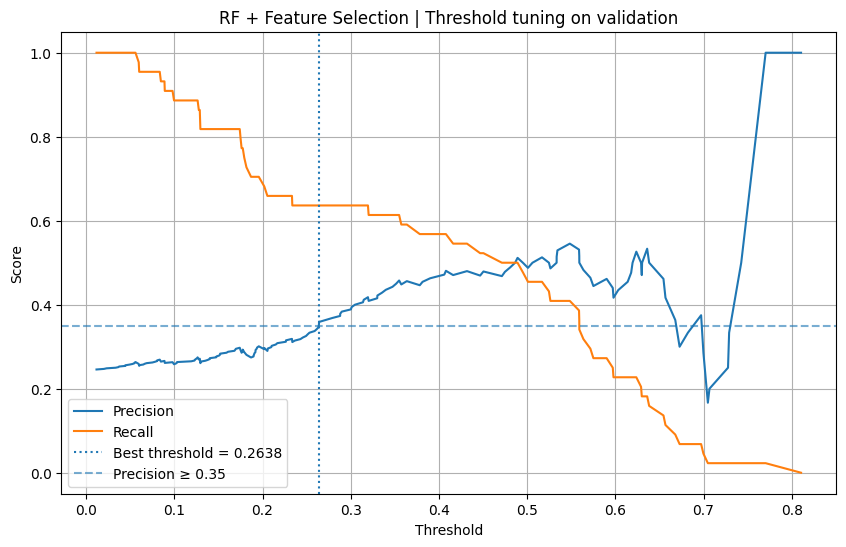

Optimal threshold: 0.2638  (Precision = 0.3500, Recall = 0.6364)


In [60]:
val_proba_rf_fs = model_rf_fs.predict_proba(X_val)[:, 1]

best_t_rf_fs, best_p_rf_fs, best_r_rf_fs = threshold_opt_recall_with_precision(
    y_true = y_val,
    y_proba = val_proba_rf_fs,
    precision_min = 0.35,
    plot = True,
    verbose = True,
    title = 'RF + Feature Selection | Threshold tuning on validation',
    save_dir = save_art,
    save_plot = 'threshold_tuning_rf_fs'
)

In [51]:
test_proba_rf_fs = model_rf_fs.predict_proba(X_test)[:, 1]
test_pred_rf_fs = (test_proba_rf_fs >= best_t_rf_fs).astype(int)

pr_auc_rf_fs = average_precision_score(y_test, test_proba_rf_fs)
print('\nTest PR-AUC =', round(pr_auc_rf_fs, 4))

print('\nConfusion Matrix (tuned threshold)')
print(confusion_matrix(y_test, test_pred_rf_fs))

print('\nClassification Report (tuned threshold)')
print(classification_report(y_test, test_pred_rf_fs, digits = 4))


Test PR-AUC = 0.6491

Confusion Matrix (tuned threshold)
[[51 24]
 [ 5 20]]

Classification Report (tuned threshold)
              precision    recall  f1-score   support

           0     0.9107    0.6800    0.7786        75
           1     0.4545    0.8000    0.5797        25

    accuracy                         0.7100       100
   macro avg     0.6826    0.7400    0.6792       100
weighted avg     0.7967    0.7100    0.7289       100



I trained a Random Forest model with embedded feature selection and tuned the decision threshold on the validation split by maximising fraud recall subject to a minimum precision constraint.<br> 
With the tuned threshold (t = 0.2638), the model achieves a test *PR-AUC of 0.6491*.<br> On the test set, it detects 20 out of 25 fraud cases (recall = 0.80) with a *fraud precision of 0.4545*, meaning 24 non-fraud claims are flagged incorrectly.<br> Overall, this variant maintains a strong fraud recall but still produces a notable number of false positives, so I compare it against the other tuned Random Forest variants before selecting the final model.

In [52]:
report_rf_fs = classification_report(y_test, test_pred_rf_fs, output_dict = True)
report_rf_fs_df = pd.DataFrame(report_rf_fs).T
report_rf_fs_df.to_csv(save_art / 'classification_report_rf_fs_tuned.csv', index = True)
print('Saving completed')

Saving completed


#### Selected Features

In [55]:
support_mask = model_rf_fs.named_steps['select'].get_support()
print('Selected features =', int(support_mask.sum()))

Selected features = 12


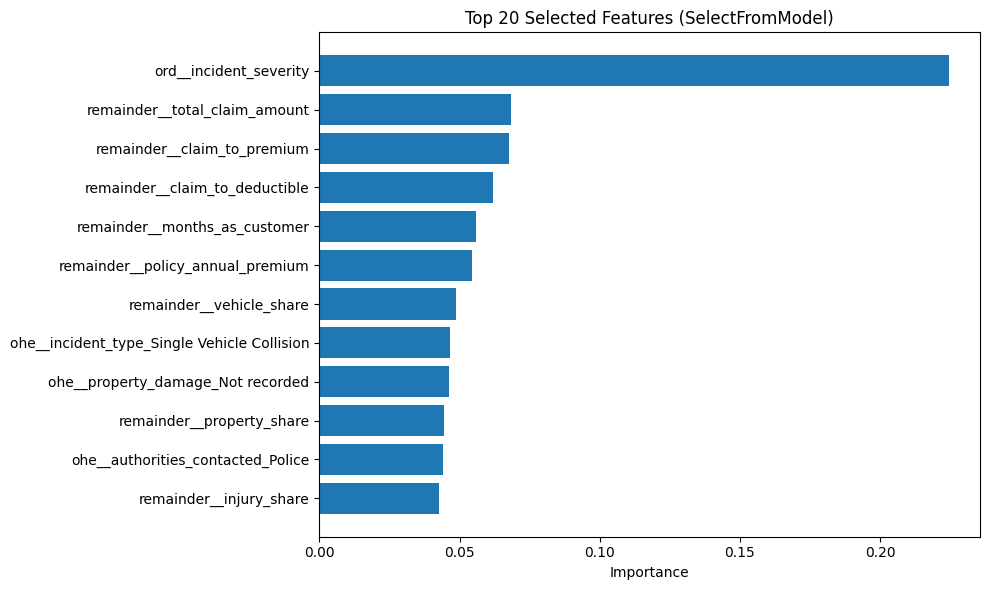

In [56]:
fs_step = model_rf_fs.named_steps['select']
rf_preprocessor = model_rf_fs.named_steps['preprocessor']

feature_names = rf_preprocessor.get_feature_names_out()
support_mask = fs_step.get_support()

selected_features = np.array(feature_names)[support_mask]
selected_importances = fs_step.estimator_.feature_importances_[support_mask]

selected_df = pd.DataFrame({
    'Feature' : selected_features,
    'Importance' : selected_importances
}).sort_values('Importance', ascending = False)

top_n = 20
top_selected = selected_df.head(top_n).sort_values('Importance')

plt.figure(figsize = (10, 6))
plt.barh(top_selected['Feature'], top_selected['Importance'])
plt.title(f'Top {top_n} Selected Features (SelectFromModel)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(save_dir / 'selected_features_rf.png', dpi = 200)
plt.show()

I plot the top selected features from the embedded selection step (SelectFromModel) to illustrate which variables remain after feature reduction and how strongly they contribute according to the selector’s impurity-based importance.<br> 
The chart shows that `incident_severity` dominates, while several engineered claim ratio/share features and a small subset of one-hot encoded incident descriptors also carry signal.<br> 
Since impurity-based importances can be biased (especially with correlated variables and one-hot encoded features), I treat this plot as a quick model-specific indication and rely on permutation importance and SHAP for the final interpretation of the selected best model.

## Performance of Random Forest Models

In [57]:
models = {
    'RF Base (tuned)' : (y_test, test_pred, test_proba),
    'RF + SMOTE (tuned)' : (y_test, test_pred_rf_smote, test_proba_rf_smote),
    'RF + FS (tuned)' : (y_test, test_pred_rf_fs, test_proba_rf_fs)
}

comparison_rows = []

for name, (y_true, y_pred, y_proba) in models.items():
    report = classification_report(y_true, y_pred, output_dict = True, zero_division = 0)
    pr_auc = average_precision_score(y_true, y_proba)

    comparison_rows.append({
        'Model' : name,
        'PR-AUC' : pr_auc,
        'Precision (Fraud)' : report['1']['precision'],
        'Recall (Fraud)' : report['1']['recall'],
        'F1 (Fraud)' : report['1']['f1-score'],
        'Precision (Non-Fraud)' : report['0']['precision'],
        'Recall (Non-Fraud)' : report['0']['recall'],
        'F1 (Non-Fraud)' : report['0']['f1-score'],
        'Accuracy' : report['accuracy']
    })

comparison_df = pd.DataFrame(comparison_rows).round(3)
comparison_df

,Model,PR-AUC,Precision (Fraud),Recall (Fraud),F1 (Fraud),Precision (Non-Fraud),Recall (Non-Fraud),F1 (Non-Fraud),Accuracy
0,RF Base (tuned),0.543,0.465,0.80,0.588,0.912,0.693,0.788,0.72
1,RF + SMOTE (tuned),0.619,0.525,0.84,0.646,0.933,0.747,0.830,0.77
2,RF + FS (tuned),0.649,0.455,0.80,0.580,0.911,0.680,0.779,0.71


In [58]:
comparison_df.to_csv(save_art / 'rf_default_comparison.csv', index = False)

**Model Comparison Summary**

I compare all Random Forest variants after calibrating the decision threshold on the validation set (maximising fraud recall under a minimum precision constraint).<br> The *RF + SMOTE* variant provides the best operational trade-off: it achieves the *highest fraud recall (0.84)* while also maintaining the *highest fraud precision (0.53)* and *F1-score (0.65)*.<br>
Although the feature selection variant yields the highest PR-AUC, it does not outperform the SMOTE model on the tuned fraud precision/recall metrics, which are my primary objective. Therefore, I select RF + SMOTE (tuned) as the final model for interpretation.

### Threshold Results

In [63]:
threshold_results = [
    {
        'Model' : 'RF Base (tuned)',
        'Best threshold' : best_t_rf_base,
        'Val precision' : best_p_rf_base,
        'Val recall' : best_r_rf_base
    },
    {
        'Model' : 'RF + SMOTE (tuned)',
        'Best threshold' : best_t_rf_smote,
        'Val precision' : best_p_rf_smote,
        'Val recall' : best_r_rf_smote
    },
    {
        'Model' : 'RF + FS (tuned)',
        'Best threshold' : best_t_rf_fs,
        'Val precision' : best_p_rf_fs,
        'Val recall' : best_r_rf_fs
    }
]

df_threshold_results = pd.DataFrame(threshold_results).round(3)
df_threshold_results

,Model,Best threshold,Val precision,Val recall
0,RF Base (tuned),0.250,0.359,0.636
1,RF + SMOTE (tuned),0.309,0.351,0.614
2,RF + FS (tuned),0.264,0.350,0.636


I summarise the selected thresholds on the validation split. Since I optimise for maximum recall under a minimum precision constraint (0.35), the chosen thresholds naturally sit near the precision boundary.<br> 
The validation recalls are similar across variants, but the final decision is based on the test performance after applying these tuned thresholds, where the RF + SMOTE model generalises best in terms of fraud precision/recall.

In [64]:
df_threshold_results.to_csv(save_art / 'topt_results.csv', index = False)

## Final Model Selection and Refit

Based on the tuned model comparison, I select the *Random Forest + SMOTE* pipeline as the final model because it provides the best fraud precision/recall trade-off under my constraint.<br> I refit the selected pipeline on the full training set to leverage all available training data. The decision threshold remains fixed at the value tuned on the validation split, and I evaluate the final model once on the test set.

In [65]:
best_threshold_rf_final = best_t_rf_smote

best_clf = best_rf_smote.named_steps['clf']

rf_smote_final = ImbPipeline([
    ( 'preprocessor', preprocessor_rf ),
    ( 'smote', SMOTE(random_state = 42) ),
    ( 'clf', RandomForestClassifier(
        random_state = 42,
        n_estimators = best_clf.n_estimators,
        max_depth = best_clf.max_depth,
        min_samples_split = best_clf.min_samples_split,
        min_samples_leaf = best_clf.min_samples_leaf,
        max_features = best_clf.max_features
    ) )
])

rf_smote_final.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ord', ...), ('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatti

In [66]:
test_proba_rf_final = rf_smote_final.predict_proba(X_test)[:, 1]
test_pred_rf_final = (test_proba_rf_final >= best_threshold_rf_final).astype(int)

pr_auc_rf_final = average_precision_score(y_test, test_proba_rf_final)
print('Final model test PR-AUC =', round(pr_auc_rf_final, 4))

print('\nConfusion Matrix (final model, tuned threshold)')
print(confusion_matrix(y_test, test_pred_rf_final))

print('\nClassification Report (final model, tuned threshold)')
print(classification_report(y_test, test_pred_rf_final, digits = 4))

Final model test PR-AUC = 0.6353

Confusion Matrix (final model, tuned threshold)
[[54 21]
 [ 5 20]]

Classification Report (final model, tuned threshold)
              precision    recall  f1-score   support

           0     0.9153    0.7200    0.8060        75
           1     0.4878    0.8000    0.6061        25

    accuracy                         0.7400       100
   macro avg     0.7015    0.7600    0.7060       100
weighted avg     0.8084    0.7400    0.7560       100



In [68]:
report_rf_final = classification_report(y_test, test_pred_rf_final, output_dict = True)
report_rf_final_df = pd.DataFrame(report_rf_final).T
report_rf_final_df.to_csv(save_art / 'classification_report_rf_final.csv', index = True)
print('Saving completed')

Saving completed


## Model Interpretation

In this section I interpret the selected final model (Random Forest + SMOTE) to understand which features drive fraud predictions.<br> I use **permutation importance** and **SHAP** as my primary interpretability methods.

In [70]:
# Using best Model

model = rf_smote_final
preprocessor = model.named_steps["preprocessor"]
clf = model.named_steps["clf"]


X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

X_shap = pd.DataFrame(X_test_processed, columns = feature_names)
X_shap_sample = X_shap.sample(n = min(500, len(X_shap)), random_state = 42)

### SHAP 

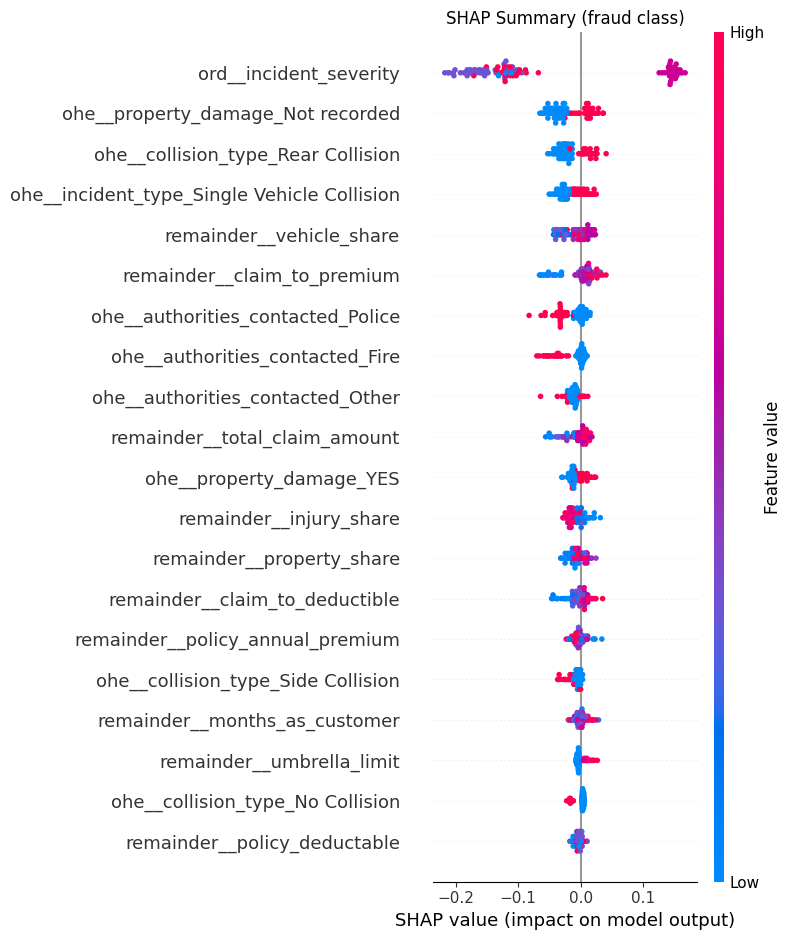

In [71]:
explainer = shap.TreeExplainer(clf)
shap_vals = explainer.shap_values(X_shap_sample) 

shap_vals_pos = shap_vals[1] if isinstance(shap_vals, list) else shap_vals[:, :, 1]

plt.figure(figsize = (8, 5))
shap.summary_plot(shap_vals_pos, X_shap_sample, show = False)
plt.title('SHAP Summary (fraud class)')
plt.tight_layout()
plt.savefig(save_art / 'shap_summary_rf_final.png', dpi = 200)
plt.show()

The SHAP summary plot shows which features drive the final model’s fraud predictions and in which direction they influence the fraud class.<br> 
The strongest driver is `incident severity`, indicating that higher severity levels push the model towards predicting fraud more strongly.<br> 
Several categorical incident descriptors also contribute meaningfully, such as `property_damage` status and `collision_type`, suggesting that specific incident circumstances are associated with higher fraud risk.<br> 
In addition, engineered numeric ratios (e.g., `claim_to_premium`, `vehicle_share`, and `total_claim_amount`) provide signal, where larger values generally increase the predicted fraud likelihood. Overall, the model combines claim magnitude/ratio features with incident context variables to identify high-risk patterns.

### Permuation Importance

I use **permutation importance** to quantify how much each feature contributes to predictive performance. I measure importance as the average decrease in PR-AUC when a feature is randomly permuted on the test set. This provides a model-agnostic complement to the SHAP analysis.

In [75]:
print('n_features (feature_names) =', len(feature_names))
print('n_features (perm means)    =', len(perm.importances_mean))
print('Pipeline steps             =', rf_smote_final.named_steps.keys())


n_features (feature_names) = 23
n_features (perm means)    = 16
Pipeline steps             = dict_keys(['preprocessor', 'smote', 'clf'])


,Feature,Importance_mean,Importance_std
6,incident_severity,0.346254,0.037182
7,authorities_contacted,0.043236,0.048192
12,property_share,0.018790,0.019380
9,total_claim_amount,0.013457,0.026148
5,collision_type,0.008956,0.036582
11,vehicle_share,0.008802,0.016621
1,policy_deductable,0.007461,0.018111
13,claim_to_premium,0.006468,0.028161
14,claim_to_deductible,0.001749,0.022301
10,injury_share,0.000189,0.013578


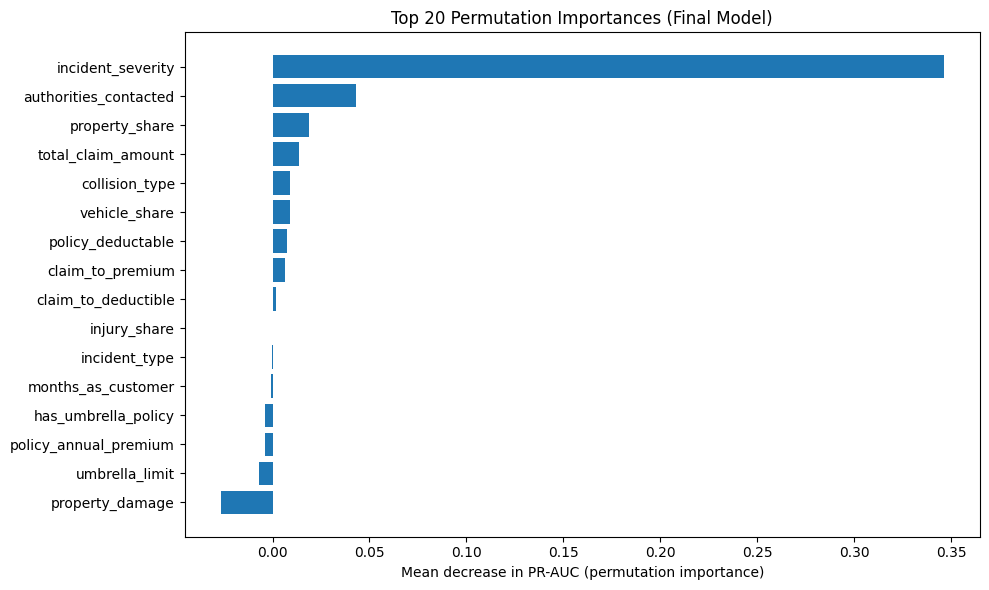

In [76]:
perm = permutation_importance(rf_smote_final,
                              X_test,
                              y_test,
                              n_repeats = 10,
                              random_state = 42,
                              scoring = 'average_precision')

feature_names = X_test.columns.to_numpy()

perm_df = (pd.DataFrame({
    'Feature': feature_names,
    'Importance_mean': perm.importances_mean,
    'Importance_std': perm.importances_std
})
.sort_values('Importance_mean', ascending = False)
)

display(perm_df.head(20))

top_n = 20
top_perm = perm_df.head(top_n).sort_values('Importance_mean')

plt.figure(figsize = (10, 6))
plt.barh(top_perm['Feature'], top_perm['Importance_mean'])
plt.xlabel('Mean decrease in PR-AUC (permutation importance)')
plt.title(f'Top {top_n} Permutation Importances (Final Model)')
plt.tight_layout()
plt.savefig(save_dir / 'permutation_importance_rf_final.png', dpi = 200)
plt.show()

I compute permutation importance on the test set and quantify importance as the mean decrease in PR-AUC when permuting each input feature.<br> The results confirm that `incident_severity` is by far the most influential variable: permuting it causes the largest performance drop.<br> Other features such as `authorities_contacted`, `property_share`, and `total_claim_amount` contribute additional signal, but their importances are smaller and less stable (high standard deviation), which is expected given the limited test set size.<br> A few variables show near-zero or slightly negative importance, indicating that they provide little consistent predictive value or overlap strongly with other correlated features.

In [77]:
perm_df.to_csv(save_art / 'perm_results.csv', index = False)

## Saving

In [79]:
# Saving Models 

models_root = Path('../models')
models_root.mkdir(parents = True, exist_ok = True)

models_root = Path('../models')
models_root.mkdir(parents = True, exist_ok = True)


# Logistic Regression 

lr_dir = models_root / 'logistic_regression'
lr_dir.mkdir(parents = True, exist_ok = True)

dump(lr_pipe, lr_dir / 'pipeline.joblib', compress = 3)

lr_meta = {
    'sklearn_version' : sklearn.__version__,
    'python' : sys.version.split()[0],
    'platform' : platform.platform(),
    'model_type' : 'LogisticRegression + Pipeline',
    'threshold' : 0.5,
    'notes' : 'Baseline linear model (no threshold tuning)'
}

with open(lr_dir / 'meta.json', 'w') as f:
    json.dump(lr_meta, f, indent = 2)

print('Saved:', lr_dir / 'pipeline.joblib')

Saved: ..\models\logistic_regression\pipeline.joblib


In [80]:
# Random Forest

rf_dir = models_root / 'random_forest_final'
rf_dir.mkdir(parents = True, exist_ok = True)

dump(rf_smote_final, rf_dir / 'pipeline.joblib', compress = 3)

rf_meta = {
    'sklearn_version' : sklearn.__version__,
    'python' : sys.version.split()[0],
    'platform' : platform.platform(),
    'model_type' : 'RandomForest + SMOTE + Pipeline',
    'threshold' : float(best_threshold_rf_final),
    'threshold_selection' : 'Validation tuning (max recall with precision >= 0.35)',
    'selected_variant' : 'rf_smote_tuned'
}

with open(rf_dir / 'meta.json', 'w') as f:
    json.dump(rf_meta, f, indent = 2)

print('Saved:', rf_dir / 'pipeline.joblib')
print('Saved:', rf_dir / 'meta.json')

Saved: ..\models\random_forest_final\pipeline.joblib
Saved: ..\models\random_forest_final\meta.json


In [81]:
# Load Model

def load_model(model_name: str, models_root: Path | str = '../models'):
    models_root = Path(models_root)
    model_dir = models_root / model_name

    model_path = model_dir / 'pipeline.joblib'
    meta_path = model_dir / 'meta.json'

    if not model_path.exists():
        raise FileNotFoundError(f'Model file not found: {model_path}')

    model = load(model_path)

    meta = None
    if meta_path.exists():
        with open(meta_path, 'r') as f:
            meta = json.load(f)

    return model, meta


In [ ]:
# rf_loaded, rf_meta_loaded = load_model('random_forest_final', models_root = models_root)
# rf_meta_loaded
